In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 01 — Exploration des données de consommation électrique

## Objectif

Cette première étape vise à comprendre la structure, la qualité et la profondeur temporelle
du jeu de données éCO2mix régional avant toute préparation destinée au Machine Learning.

L'analyse porte notamment sur :

- la volumétrie du dataset ;
- la période couverte ;
- les régions disponibles ;
- la fréquence temporelle des observations ;
- les types de variables ;
- les valeurs manquantes ;
- l'évolution de la complétude selon les années ;
- les doublons et ruptures temporelles éventuelles ;
- la distribution de la consommation électrique.

L'objectif final de cette exploration est de sélectionner une période et un périmètre
géographique suffisamment fiables pour construire le futur jeu de données d'apprentissage.

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "eco2mix-regional-cons-def.csv"
)

DATA_PATH

WindowsPath('c:/Users/audrencorre/OneDrive - GROUPE BERNARD/Documents/RNCP_BLOC_5/data/raw/eco2mix-regional-cons-def.csv')

In [4]:
sample = pd.read_csv(
    DATA_PATH,
    sep=";",
    nrows=10
)

sample

,Code INSEE région,Région,Nature,Date,Heure,Date - Heure,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Column 30
0,53,Bretagne,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,76,Occitanie,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28,Normandie,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,32,Hauts-de-France,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,Île-de-France,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,75,Nouvelle-Aquitaine,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,84,Auvergne-Rhône-Alpes,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,27,Bourgogne-Franche-Comté,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,44,Grand Est,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,24,Centre-Val de Loire,Données définitives,2013-01-01,00:00,2012-12-31T23:00:00+00:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
sample.columns.tolist()

['Code INSEE région',
 'Région',
 'Nature',
 'Date',
 'Heure',
 'Date - Heure',
 'Consommation (MW)',
 'Thermique (MW)',
 'Nucléaire (MW)',
 'Eolien (MW)',
 'Solaire (MW)',
 'Hydraulique (MW)',
 'Pompage (MW)',
 'Bioénergies (MW)',
 'Ech. physiques (MW)',
 'Stockage batterie',
 'Déstockage batterie',
 'Eolien terrestre',
 'Eolien offshore',
 'TCO Thermique (%)',
 'TCH Thermique (%)',
 'TCO Nucléaire (%)',
 'TCH Nucléaire (%)',
 'TCO Eolien (%)',
 'TCH Eolien (%)',
 'TCO Solaire (%)',
 'TCH Solaire (%)',
 'TCO Hydraulique (%)',
 'TCH Hydraulique (%)',
 'TCO Bioénergies (%)',
 'TCH Bioénergies (%)',
 'Column 30']

In [6]:
df = pd.read_csv(
    DATA_PATH,
    sep=";",
    na_values=["ND", "N/A", ""],
    low_memory=False
)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2839104 entries, 0 to 2839103
Data columns (total 32 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Code INSEE région    int64  
 1   Région               str    
 2   Nature               str    
 3   Date                 str    
 4   Heure                str    
 5   Date - Heure         str    
 6   Consommation (MW)    float64
 7   Thermique (MW)       float64
 8   Nucléaire (MW)       float64
 9   Eolien (MW)          str    
 10  Solaire (MW)         float64
 11  Hydraulique (MW)     float64
 12  Pompage (MW)         float64
 13  Bioénergies (MW)     float64
 14  Ech. physiques (MW)  float64
 15  Stockage batterie    float64
 16  Déstockage batterie  float64
 17  Eolien terrestre     float64
 18  Eolien offshore      float64
 19  TCO Thermique (%)    float64
 20  TCH Thermique (%)    float64
 21  TCO Nucléaire (%)    float64
 22  TCH Nucléaire (%)    float64
 23  TCO Eolien (%)       float64
 24  TCH Eolie

In [26]:
df.isna().mean()

Code INSEE région      0.000000
Région                 0.000000
Nature                 0.000000
Date                   0.000000
Heure                  0.000000
Date - Heure           0.000000
Consommation (MW)      0.000004
Thermique (MW)         0.000004
Nucléaire (MW)         0.247010
Eolien (MW)            0.000004
Solaire (MW)           0.000004
Hydraulique (MW)       0.000004
Pompage (MW)           0.259352
Bioénergies (MW)       0.000004
Ech. physiques (MW)    0.000004
Stockage batterie      0.592822
Déstockage batterie    0.592822
Eolien terrestre       0.592822
Eolien offshore        0.592822
TCO Thermique (%)      0.518564
TCH Thermique (%)      0.518564
TCO Nucléaire (%)      0.549503
TCH Nucléaire (%)      0.719162
TCO Eolien (%)         0.518564
TCH Eolien (%)         0.518564
TCO Solaire (%)        0.518564
TCH Solaire (%)        0.518564
TCO Hydraulique (%)    0.518564
TCH Hydraulique (%)    0.518564
TCO Bioénergies (%)    0.518564
TCH Bioénergies (%)    0.518564
Année   

### Colonne entièrement vide

La colonne `Column 30` ne contient aucune valeur renseignée sur l'ensemble du jeu de données.

Elle n'apporte donc aucune information exploitable pour l'analyse ou la modélisation et sera supprimée lors de la phase de préparation.


In [25]:
df.drop(columns="Column 30", inplace=True)

In [8]:
df["Date - Heure"] = pd.to_datetime(
    df["Date - Heure"],
    utc=True,
    errors="coerce"
)

In [10]:
df["Année"] = df["Date - Heure"].dt.year

In [11]:
df["Année"].value_counts().sort_index()

Année
2012        24
2013    210240
2014    210240
2015    210240
2016    210816
2017    210240
2018    210240
2019    210240
2020    210816
2021    210240
2022    210240
2023    210240
2024    210816
2025    210240
2026    104232
Name: count, dtype: int64

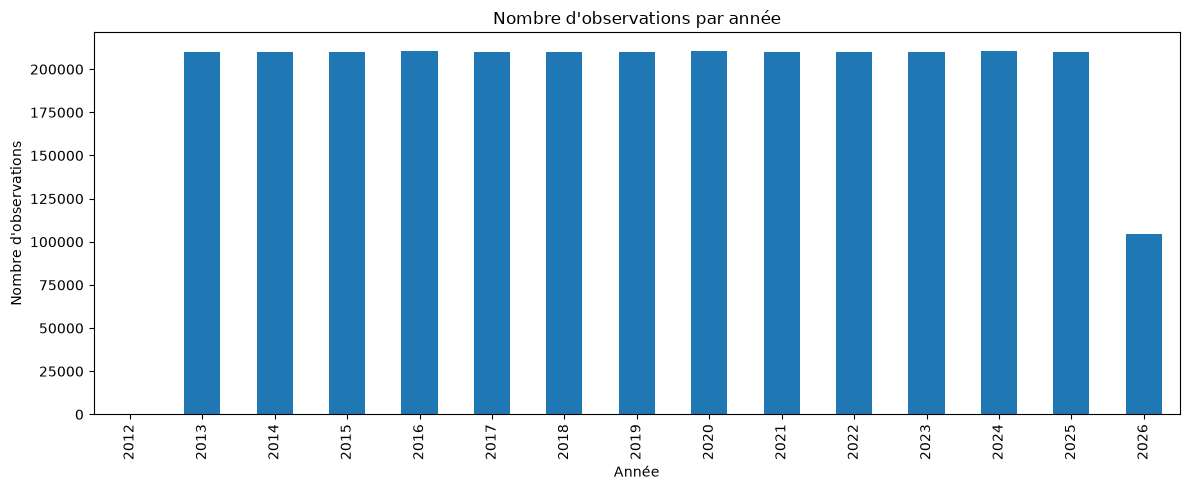

In [12]:
df["Année"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Nombre d'observations par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

In [14]:
observations_region_annee = pd.crosstab(
    df["Année"],
    df["Région"]
)

observations_region_annee

Région,Auvergne-Rhône-Alpes,Bourgogne-Franche-Comté,Bretagne,Centre-Val de Loire,Grand Est,Hauts-de-France,Normandie,Nouvelle-Aquitaine,Occitanie,Pays de la Loire,Provence-Alpes-Côte d'Azur,Île-de-France
Année,,,,,,,,,,,,
2012,2,2,2,2,2,2,2,2,2,2,2,2
2013,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520
2014,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520
2015,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520
2016,17568,17568,17568,17568,17568,17568,17568,17568,17568,17568,17568,17568
2017,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520
2018,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520
2019,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520,17520
2020,17568,17568,17568,17568,17568,17568,17568,17568,17568,17568,17568,17568


In [15]:
region_test = "Nouvelle-Aquitaine"

df_region = (
    df[df["Région"] == region_test]
    .sort_values("Date - Heure")
    .copy()
)

In [16]:
df_region["delta_t"] = (
    df_region["Date - Heure"]
    .diff()
)

In [17]:
df_region["delta_t"].value_counts().head(10)

delta_t
0 days 00:30:00    236550
0 days 00:00:00        28
0 days 01:30:00        13
Name: count, dtype: int64

### Analyse des doublons temporels

Les doublons détectés sur la clé `Région + Date - Heure` se concentrent autour des changements d’heure légale, fin mars et fin octobre.

Ce comportement s’explique par le passage entre heure d’hiver et heure d’été, qui modifie la correspondance entre heure locale et heure UTC. Certaines heures peuvent alors être répétées ou absentes selon la période.

Ces lignes ne sont donc pas considérées comme des doublons purs car la colonne Heure diffère mais il s'agit bel et bien du même relevé à deux heures différentes.

La reconstruction d’un index temporel cohérent avec le fuseau `Europe/Paris` sera réalisée lors de la phase de préparation des données.

In [19]:
duplicates = df.duplicated(
    subset=["Région", "Date - Heure"],
    keep=False
)

print("Nombre de lignes en doublon :", duplicates.sum())

Nombre de lignes en doublon : 672


In [21]:
df[duplicates]

,Code INSEE région,Région,Nature,Date,Heure,Date - Heure,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),...,TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Column 30,Année
51312,27,Bourgogne-Franche-Comté,Données définitives,2013-03-31,02:00,2013-03-31 01:00:00+00:00,2588.0,145.0,NaN,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013
51313,27,Bourgogne-Franche-Comté,Données définitives,2013-03-31,03:00,2013-03-31 01:00:00+00:00,2588.0,145.0,NaN,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013
51314,28,Normandie,Données définitives,2013-03-31,02:00,2013-03-31 01:00:00+00:00,4402.0,778.0,8111.0,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013
51315,11,Île-de-France,Données définitives,2013-03-31,02:00,2013-03-31 01:00:00+00:00,9468.0,917.0,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013
51316,11,Île-de-France,Données définitives,2013-03-31,03:00,2013-03-31 01:00:00+00:00,9468.0,917.0,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2785051,84,Auvergne-Rhône-Alpes,Données consolidées,2026-03-29,02:30,2026-03-29 01:30:00+00:00,8059.0,101.0,8388.0,509,...,6.32,64.84,0.0,0.0,39.10,27.51,1.56,65.63,NaN,2026
2785052,53,Bretagne,Données consolidées,2026-03-29,02:30,2026-03-29 01:30:00+00:00,2662.0,213.0,0.0,654,...,24.57,33.00,0.0,0.0,0.45,4.36,1.84,62.82,NaN,2026
2785053,53,Bretagne,Données consolidées,2026-03-29,03:30,2026-03-29 01:30:00+00:00,2662.0,213.0,0.0,654,...,24.57,33.00,0.0,0.0,0.45,4.36,1.84,62.82,NaN,2026
2785054,52,Pays de la Loire,Données consolidées,2026-03-29,02:30,2026-03-29 01:30:00+00:00,3029.0,101.0,0.0,1032,...,34.07,43.93,0.0,0.0,0.17,50.00,1.78,60.00,NaN,2026


## Analyse de la complétude des variables

Les premières années du jeu de données présentent davantage de valeurs manquantes,
notamment pour certaines filières de production et certains indicateurs dérivés.

L'objectif de cette étape est de mesurer la complétude des variables par année afin
d'identifier une période suffisamment fiable pour la modélisation.

In [27]:
variables_etudiees = [
    "Consommation (MW)",
    "Thermique (MW)",
    "Nucléaire (MW)",
    "Eolien (MW)",
    "Solaire (MW)",
    "Hydraulique (MW)",
    "Pompage (MW)",
    "Bioénergies (MW)",
    "Ech. physiques (MW)",
    "Stockage batterie",
    "Déstockage batterie",
    "Eolien terrestre",
    "Eolien offshore",
]

In [28]:
completude_par_annee = (
    df.groupby("Année")[variables_etudiees]
    .agg(lambda s: s.notna().mean() * 100)
)

completude_par_annee.round(2)

,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),Solaire (MW),Hydraulique (MW),Pompage (MW),Bioénergies (MW),Ech. physiques (MW),Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
Année,,,,,,,,,,,,,
2012,50.0,50.0,29.17,50.0,50.0,50.0,25.00,50.0,50.0,0.00,0.00,0.00,0.00
2013,100.0,100.0,58.33,100.0,100.0,100.0,50.00,100.0,100.0,0.00,0.00,0.00,0.00
2014,100.0,100.0,58.33,100.0,100.0,100.0,50.00,100.0,100.0,0.00,0.00,0.00,0.00
2015,100.0,100.0,58.33,100.0,100.0,100.0,58.33,100.0,100.0,0.00,0.00,0.00,0.00
2016,100.0,100.0,58.33,100.0,100.0,100.0,58.33,100.0,100.0,0.00,0.00,0.00,0.00
2017,100.0,100.0,58.33,100.0,100.0,100.0,58.33,100.0,100.0,0.00,0.00,0.00,0.00
2018,100.0,100.0,58.33,100.0,100.0,100.0,58.33,100.0,100.0,0.00,0.00,0.00,0.00
2019,100.0,100.0,58.33,100.0,100.0,100.0,58.33,100.0,100.0,0.00,0.00,0.00,0.00
2020,100.0,100.0,58.34,100.0,100.0,100.0,58.34,100.0,100.0,0.01,0.01,0.01,0.01


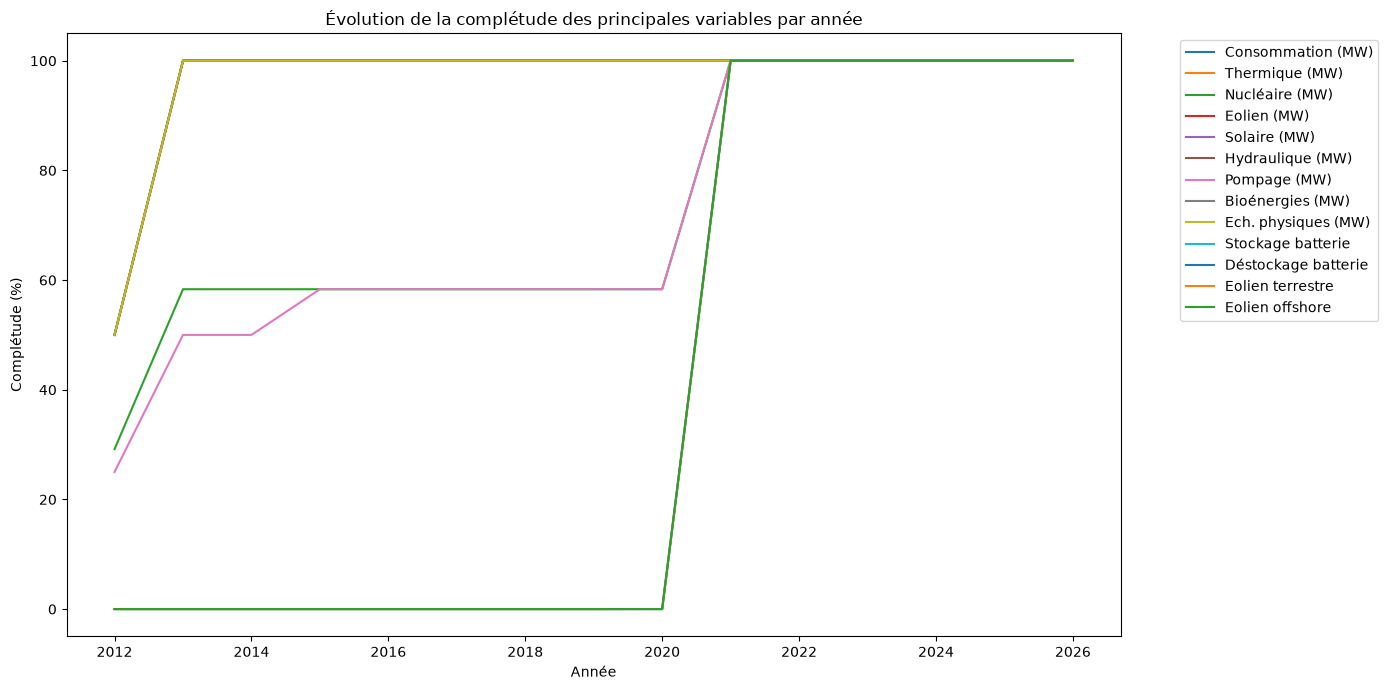

In [29]:
completude_par_annee.plot(
    figsize=(14, 7)
)

plt.title("Évolution de la complétude des principales variables par année")
plt.xlabel("Année")
plt.ylabel("Complétude (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [30]:
variables_cle = [
    "Consommation (MW)",
    "Thermique (MW)",
    "Nucléaire (MW)",
    "Eolien (MW)",
    "Solaire (MW)",
    "Hydraulique (MW)",
    "Bioénergies (MW)",
    "Ech. physiques (MW)",
]

completude_cle = (
    df.groupby("Année")[variables_cle]
    .agg(lambda s: s.notna().mean() * 100)
)

completude_cle.round(2)

,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),Solaire (MW),Hydraulique (MW),Bioénergies (MW),Ech. physiques (MW)
Année,,,,,,,,
2012,50.0,50.0,29.17,50.0,50.0,50.0,50.0,50.0
2013,100.0,100.0,58.33,100.0,100.0,100.0,100.0,100.0
2014,100.0,100.0,58.33,100.0,100.0,100.0,100.0,100.0
2015,100.0,100.0,58.33,100.0,100.0,100.0,100.0,100.0
2016,100.0,100.0,58.33,100.0,100.0,100.0,100.0,100.0
2017,100.0,100.0,58.33,100.0,100.0,100.0,100.0,100.0
2018,100.0,100.0,58.33,100.0,100.0,100.0,100.0,100.0
2019,100.0,100.0,58.33,100.0,100.0,100.0,100.0,100.0
2020,100.0,100.0,58.34,100.0,100.0,100.0,100.0,100.0


In [31]:
pd.crosstab(
    df["Année"],
    df["Nature"]
)

Nature,Données consolidées,Données définitives
Année,,
2012,0,24
2013,0,210240
2014,0,210240
2015,0,210240
2016,0,210816
2017,0,210240
2018,0,210240
2019,0,210240
2020,0,210816


In [32]:
df["Consommation (MW)"].describe()

count    2.839092e+06
mean     4.400354e+03
std      2.117886e+03
min      0.000000e+00
25%      2.721000e+03
50%      4.049000e+03
75%      5.601000e+03
max      1.533800e+04
Name: Consommation (MW), dtype: float64

In [33]:
df.groupby("Année")["Consommation (MW)"].agg(
    ["count", "mean", "std", "min", "max"]
).round(2)

,count,mean,std,min,max
Année,,,,,
2012,12,4971.83,2123.23,2357.0,9134.0
2013,210240,4681.33,2309.27,1021.0,15286.0
2014,210240,4398.39,2115.52,1022.0,13723.0
2015,210240,4500.94,2193.40,1009.0,14749.0
2016,210816,4556.88,2202.09,1027.0,15148.0
2017,210240,4556.98,2229.91,1045.0,15250.0
2018,210240,4523.63,2195.83,1076.0,15338.0
2019,210240,4475.65,2122.89,895.0,14402.0
2020,210816,4236.71,1978.68,1041.0,13781.0


In [34]:
na = (
    df[df["Région"] == "Nouvelle-Aquitaine"]
    .sort_values("Date - Heure")
    .copy()
)

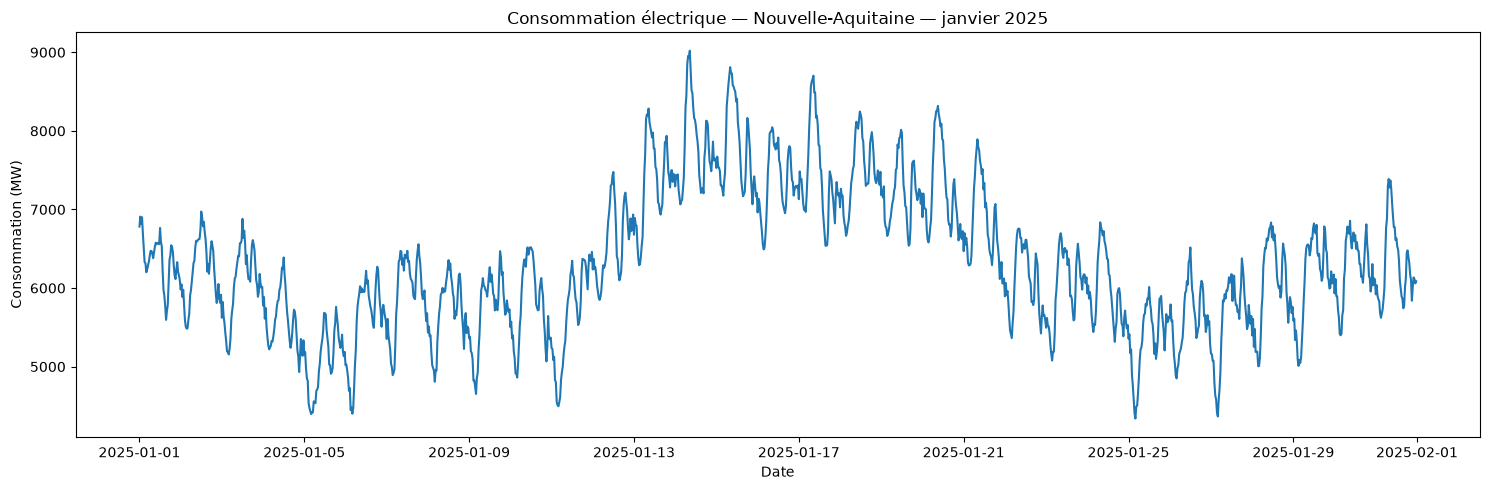

In [35]:
periode = na[
    (na["Date - Heure"] >= "2025-01-01")
    & (na["Date - Heure"] < "2025-02-01")
]

plt.figure(figsize=(15, 5))

plt.plot(
    periode["Date - Heure"],
    periode["Consommation (MW)"]
)

plt.title("Consommation électrique — Nouvelle-Aquitaine — janvier 2025")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.tight_layout()
plt.show()

### Interprétation de la complétude

La présence de valeurs manquantes dans certaines variables de production ne traduit pas
nécessairement un défaut de qualité des données.

Certaines filières de production ne sont pas présentes dans toutes les régions françaises.
Une absence de valeur pour le nucléaire, le pompage, l'éolien offshore ou le stockage
peut donc correspondre à une caractéristique structurelle du territoire plutôt qu'à une
observation manquante.

La complétude devra par conséquent être étudiée au niveau régional avant toute décision
d'imputation ou de suppression de variables.

In [36]:
completude_region = (
    df.groupby("Région")[variables_etudiees]
    .agg(lambda s: s.notna().mean() * 100)
)

completude_region.round(2)

,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),Solaire (MW),Hydraulique (MW),Pompage (MW),Bioénergies (MW),Ech. physiques (MW),Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
Région,,,,,,,,,,,,,
Auvergne-Rhône-Alpes,100.0,100.0,100.00,100.0,100.0,100.0,100.00,100.0,100.0,40.72,40.72,40.72,40.72
Bourgogne-Franche-Comté,100.0,100.0,40.72,100.0,100.0,100.0,100.00,100.0,100.0,40.72,40.72,40.72,40.72
Bretagne,100.0,100.0,40.72,100.0,100.0,100.0,100.00,100.0,100.0,40.72,40.72,40.72,40.72
Centre-Val de Loire,100.0,100.0,100.00,100.0,100.0,100.0,40.72,100.0,100.0,40.72,40.72,40.72,40.72
Grand Est,100.0,100.0,100.00,100.0,100.0,100.0,100.00,100.0,100.0,40.72,40.72,40.72,40.72
Hauts-de-France,100.0,100.0,100.00,100.0,100.0,100.0,85.19,100.0,100.0,40.72,40.72,40.72,40.72
Normandie,100.0,100.0,100.00,100.0,100.0,100.0,40.72,100.0,100.0,40.72,40.72,40.72,40.72
Nouvelle-Aquitaine,100.0,100.0,100.00,100.0,100.0,100.0,40.72,100.0,100.0,40.72,40.72,40.72,40.72
Occitanie,100.0,100.0,100.00,100.0,100.0,100.0,100.00,100.0,100.0,40.72,40.72,40.72,40.72


In [37]:
completude_na_annee = (
    df[df["Région"] == "Nouvelle-Aquitaine"]
    .groupby("Année")[variables_etudiees]
    .agg(lambda s: s.notna().mean() * 100)
)

completude_na_annee.round(2)

,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),Solaire (MW),Hydraulique (MW),Pompage (MW),Bioénergies (MW),Ech. physiques (MW),Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
Année,,,,,,,,,,,,,
2012,50.0,50.0,50.0,50.0,50.0,50.0,0.00,50.0,50.0,0.00,0.00,0.00,0.00
2013,100.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,100.0,0.00,0.00,0.00,0.00
2014,100.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,100.0,0.00,0.00,0.00,0.00
2015,100.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,100.0,0.00,0.00,0.00,0.00
2016,100.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,100.0,0.00,0.00,0.00,0.00
2017,100.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,100.0,0.00,0.00,0.00,0.00
2018,100.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,100.0,0.00,0.00,0.00,0.00
2019,100.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,100.0,0.00,0.00,0.00,0.00
2020,100.0,100.0,100.0,100.0,100.0,100.0,0.01,100.0,100.0,0.01,0.01,0.01,0.01


In [38]:
df.loc[
    df["Consommation (MW)"] <= 0,
    [
        "Région",
        "Nature",
        "Date",
        "Heure",
        "Date - Heure",
        "Consommation (MW)"
    ]
]

,Région,Nature,Date,Heure,Date - Heure,Consommation (MW)
2706923,Auvergne-Rhône-Alpes,Données consolidées,2025-11-13,12:00,2025-11-13 11:00:00+00:00,0.0


In [39]:
(df["Consommation (MW)"] <= 0).sum()

np.int64(1)

### Anomalie de relevé suspectée

Une consommation régionale de 0 MW est strictement impossible et cette valeur est très probablement une anomalie. Aucune explication n'a été trouvée et la valeur doit être supprimée pour le bien de l'entraînement futur

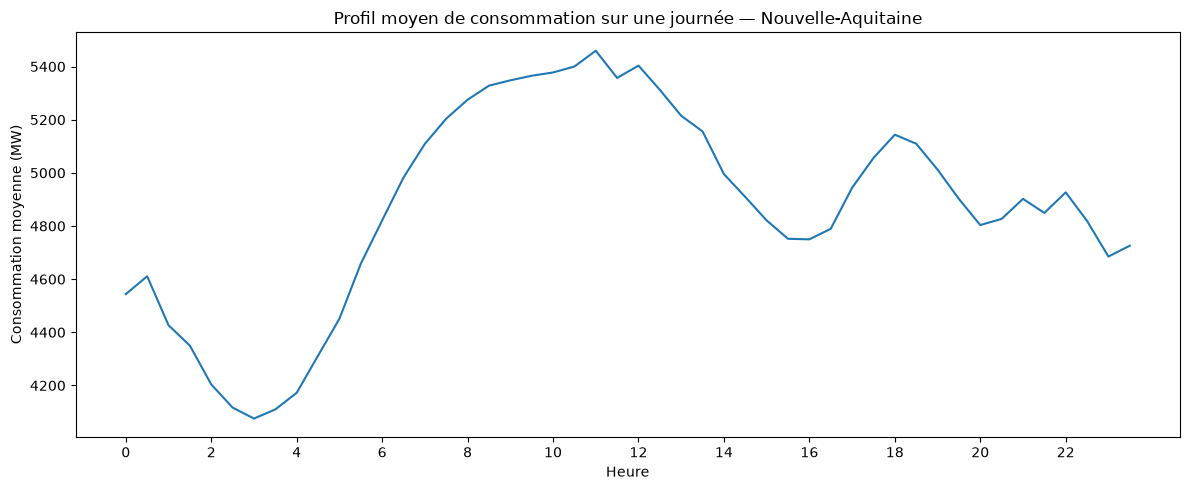

In [40]:
na["minute_jour"] = (
    na["Date - Heure"].dt.hour * 60
    + na["Date - Heure"].dt.minute
)

profil_intrajournalier = (
    na.groupby("minute_jour")["Consommation (MW)"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(
    profil_intrajournalier.index / 60,
    profil_intrajournalier.values
)

plt.title("Profil moyen de consommation sur une journée — Nouvelle-Aquitaine")
plt.xlabel("Heure")
plt.ylabel("Consommation moyenne (MW)")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

In [41]:
na["jour_semaine"] = na["Date - Heure"].dt.dayofweek

jours = {
    0: "Lundi",
    1: "Mardi",
    2: "Mercredi",
    3: "Jeudi",
    4: "Vendredi",
    5: "Samedi",
    6: "Dimanche"
}

profil_jour = (
    na.groupby("jour_semaine")["Consommation (MW)"]
    .mean()
    .rename(index=jours)
)

profil_jour

jour_semaine
Lundi       4953.679342
Mardi       5051.267792
Mercredi    5046.420573
Jeudi       5034.648438
Vendredi    4979.441761
Samedi      4610.511571
Dimanche    4428.853258
Name: Consommation (MW), dtype: float64

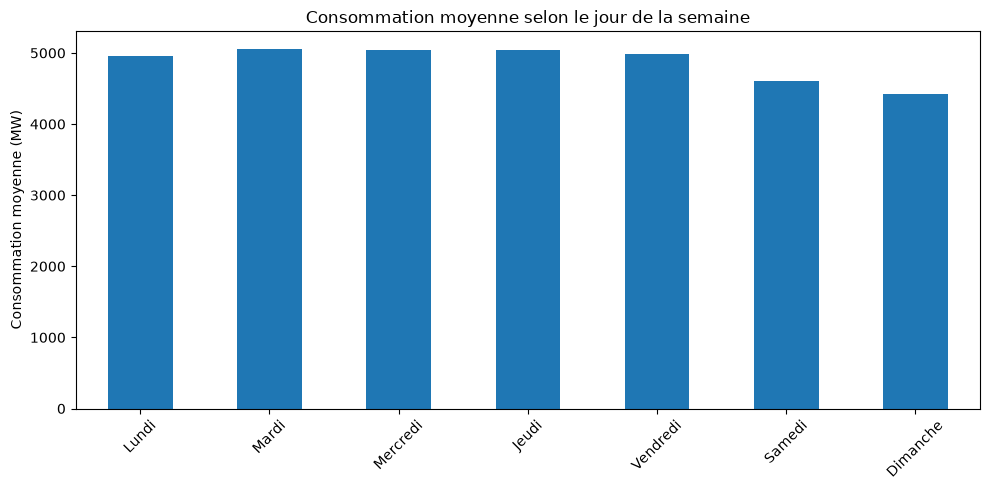

In [42]:
profil_jour.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Consommation moyenne selon le jour de la semaine")
plt.xlabel("")
plt.ylabel("Consommation moyenne (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

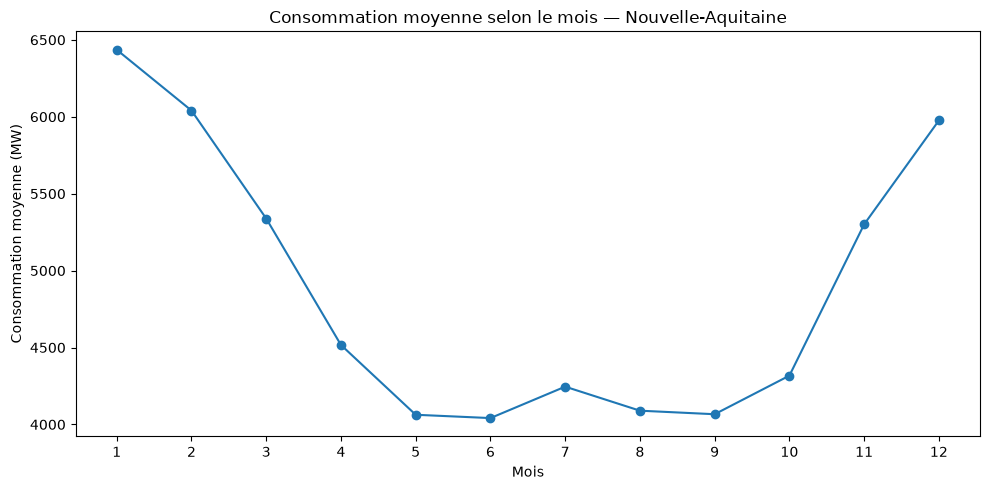

In [43]:
na["mois"] = na["Date - Heure"].dt.month

profil_mensuel = (
    na.groupby("mois")["Consommation (MW)"]
    .mean()
)

profil_mensuel.plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Consommation moyenne selon le mois — Nouvelle-Aquitaine")
plt.xlabel("Mois")
plt.ylabel("Consommation moyenne (MW)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [44]:
na["heure_decimal"] = (
    na["Date - Heure"].dt.hour
    + na["Date - Heure"].dt.minute / 60
)

heatmap_data = (
    na.groupby(["jour_semaine", "heure_decimal"])["Consommation (MW)"]
    .mean()
    .unstack()
)

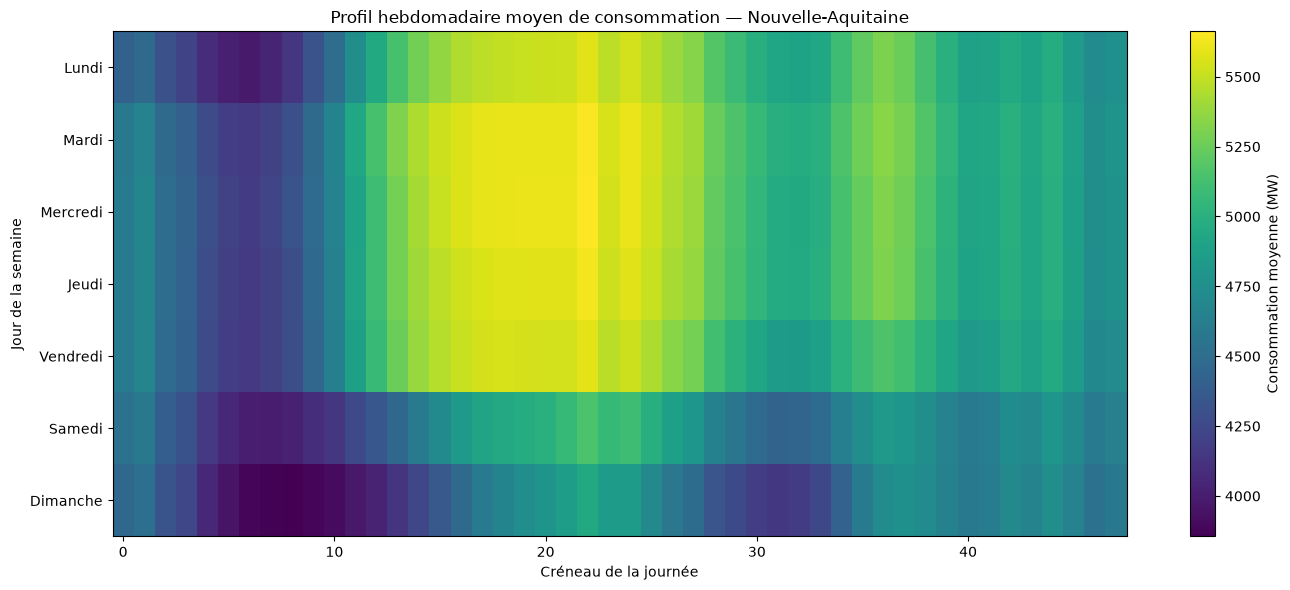

In [45]:
plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Consommation moyenne (MW)")
plt.yticks(
    range(7),
    [jours[i] for i in range(7)]
)

plt.xlabel("Créneau de la journée")
plt.ylabel("Jour de la semaine")
plt.title("Profil hebdomadaire moyen de consommation — Nouvelle-Aquitaine")
plt.tight_layout()
plt.show()

## Conclusion intermédiaire

Le jeu de données présente une profondeur temporelle importante, avec des observations
régionales à un pas de 30 minutes depuis 2013.

La variable `Consommation (MW)`, qui constituera la base de la variable cible, est presque
entièrement renseignée sur la période étudiée.

Certaines variables relatives aux filières de production présentent une complétude plus
faible. Cette observation doit cependant être interprétée au niveau régional, certaines
filières n'étant pas présentes dans tous les territoires.

Les données sont définitives jusqu'à l'essentiel de l'année 2024, tandis que les années
2025 et 2026 sont fournies sous forme consolidée.

L'analyse temporelle met également en évidence des particularités liées aux changements
d'heure et quelques valeurs atypiques qui devront être traitées lors de la préparation.

La profondeur et la fréquence du jeu de données sont suffisantes pour envisager un
problème de prévision de consommation électrique par Machine Learning.

## Synthèse de l'exploration

L'analyse du jeu de données éCO2mix régional confirme sa pertinence pour un projet
de prévision de consommation électrique.

Le dataset contient près de 2,84 millions d'observations régionales et couvre la période
allant de fin 2012 à 2026. Pour une année complète, chaque région dispose d'environ
17 520 observations, correspondant à un pas temporel de 30 minutes.

La variable `Consommation (MW)`, retenue comme base de la future variable cible,
est quasiment entièrement renseignée à partir de 2013.

Certaines variables de production présentent des valeurs absentes selon les régions.
Ces absences ne correspondent pas systématiquement à un défaut de qualité des données,
certaines filières de production n'étant pas implantées dans tous les territoires.

L'analyse temporelle de la Nouvelle-Aquitaine met en évidence plusieurs saisonnalités :

- un profil de consommation dépendant fortement de l'heure de la journée ;
- une consommation plus faible le week-end ;
- une variation saisonnière importante au cours de l'année.

Ces observations justifient la future construction de variables calendaires et de variables
retardées à partir de l'historique de consommation.

Des anomalies limitées ont également été identifiées :

- des doublons associés aux changements d'heure ;
- une valeur de consommation nulle isolée ;
- une complétude moindre de certaines variables sur les périodes anciennes.

Ces éléments seront traités lors de l'étape de préparation des données.

## Décision de périmètre pour la modélisation

À l'issue de l'analyse exploratoire, le périmètre suivant est retenu pour la première version du projet :

- **Zone étudiée :** Nouvelle-Aquitaine
- **Granularité temporelle :** 30 minutes
- **Période de travail :** années récentes suffisamment complètes, à partir de 2019
- **Variable cible :** consommation électrique future en MW
- **Horizon de prévision :** consommation à J+1 au même créneau horaire, soit `t+48`
- **Type de problème :** régression sur série temporelle

Ce choix permet de disposer d'un volume de données suffisant tout en conservant un périmètre maîtrisable.

L'analyse a également mis en évidence plusieurs facteurs susceptibles d'expliquer la consommation :

- heure de la journée ;
- jour de la semaine ;
- saison ;
- historique récent de consommation ;
- consommation au même créneau les jours précédents ;
- variables calendaires ;
- données météorologiques à intégrer dans une étape ultérieure.

La prochaine étape consiste à préparer le jeu de données supervisé, construire la cible `t+48`, générer les variables explicatives et traiter les anomalies identifiées lors de l'exploration.